# plot styling

yabplot provides several styling presets and customization options to make your figures publication-ready.

in this tutorial, we will explore:
1. lighting styles.
2. customizing the background context brain.
3. handling missing data (`nan_color`, `nan_alpha`).
4. tract-specific visualizations.
5. region boundary contours (`draw_contours`).

In [1]:
import yabplot as yab
import matplotlib.pyplot as plt
import numpy as np

## 1. lighting styles
different styles can highlight shape (sculpted) or data values (flat/matte). available styles include: `'default'`, `'matte'`, `'glossy'`, `'sculpted'`, `'flat'`.

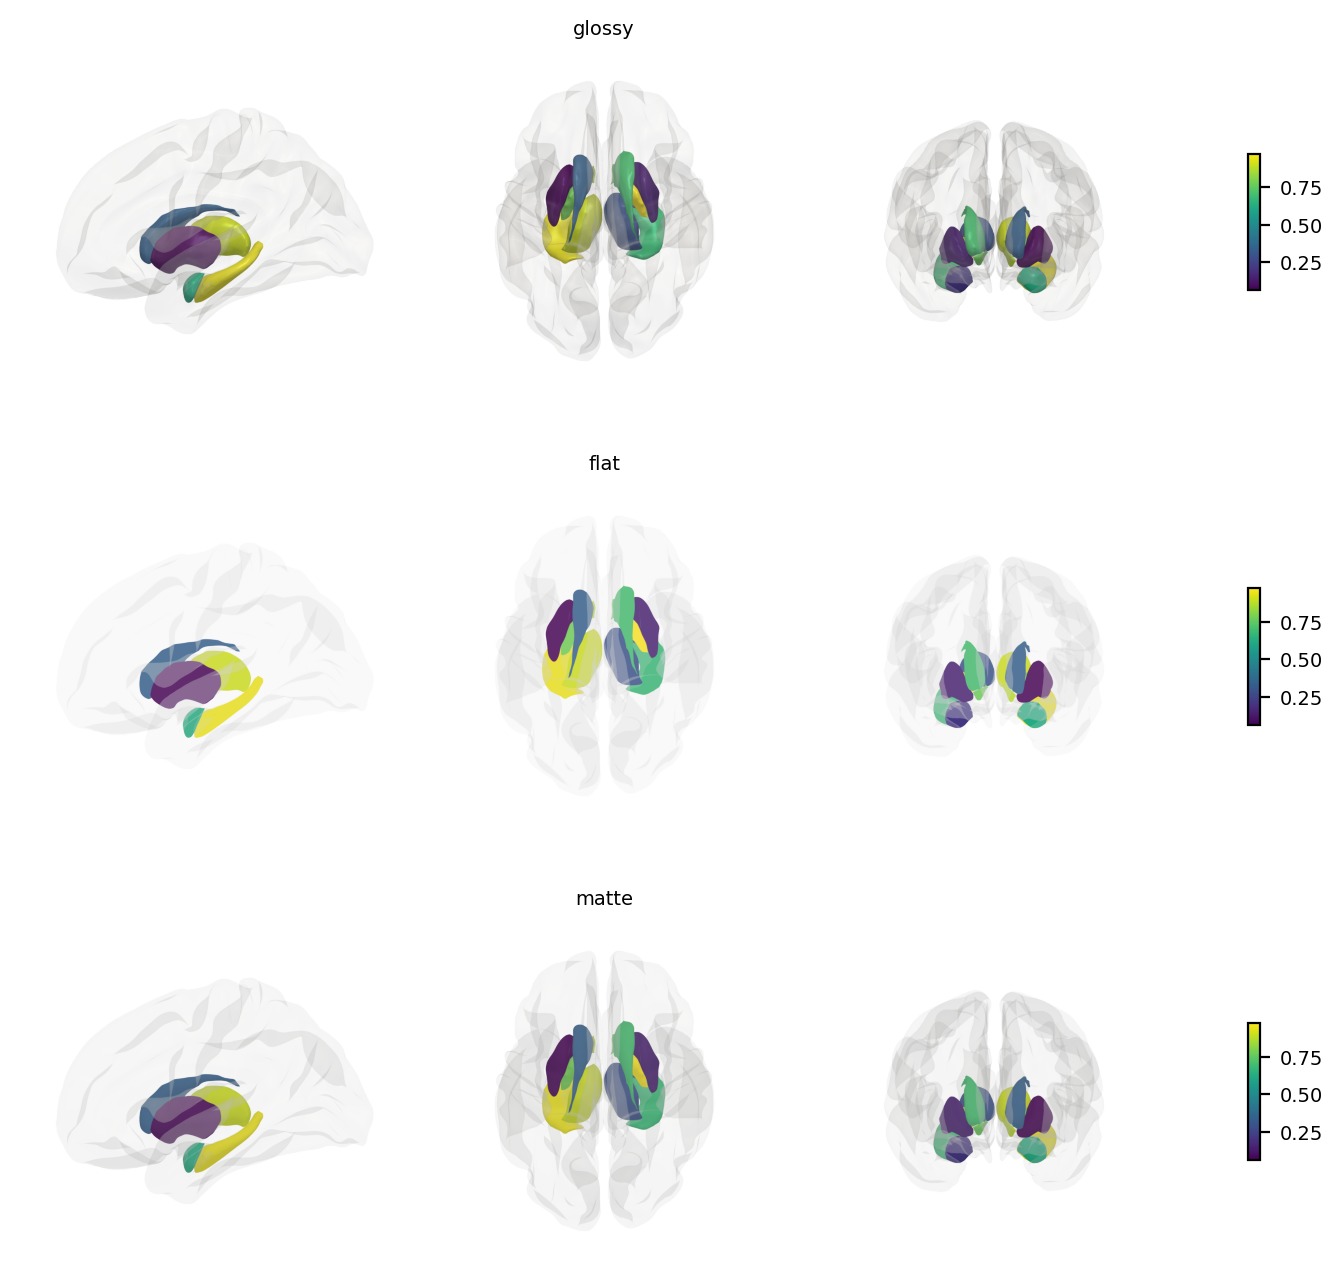

In [ ]:
# generate random data for demonstration
regions = yab.get_atlas_regions('aseg', 'subcortical')
data = np.random.rand(len(regions))

fig, axes = plt.subplots(3, 1, figsize=(8, 8), dpi=200)

# compare 'flat' vs 'glossy' vs 'matte' styles
# - glossy enhances the 3d curvature giving it a shiny look
# - flat is great for seeing exact data colors without shadows
# - matte is a balance between both
for i, style in enumerate(['glossy', 'flat', 'matte']):
    axes[i] = yab.plot_subcortical(
        data=data,
        ax = axes[i],
        cmap='viridis',
        atlas='aseg',
        views=['left_lateral', 'superior', 'anterior'],
        style=style
    )
    axes[i].set_title(style, fontsize=7)

## 2. context brain (bmesh)
for subcortical and tract plots, a context brain mesh is rendered to show anatomical location. you can change its style or hide it.

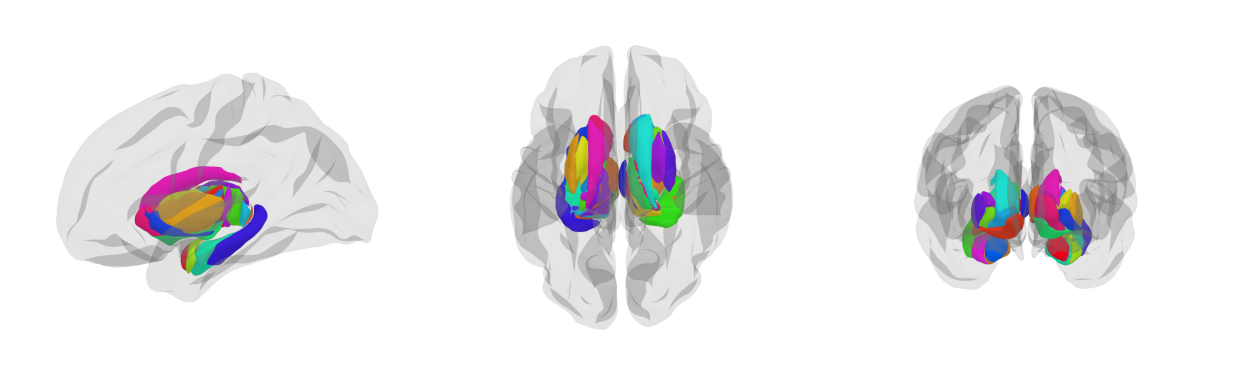

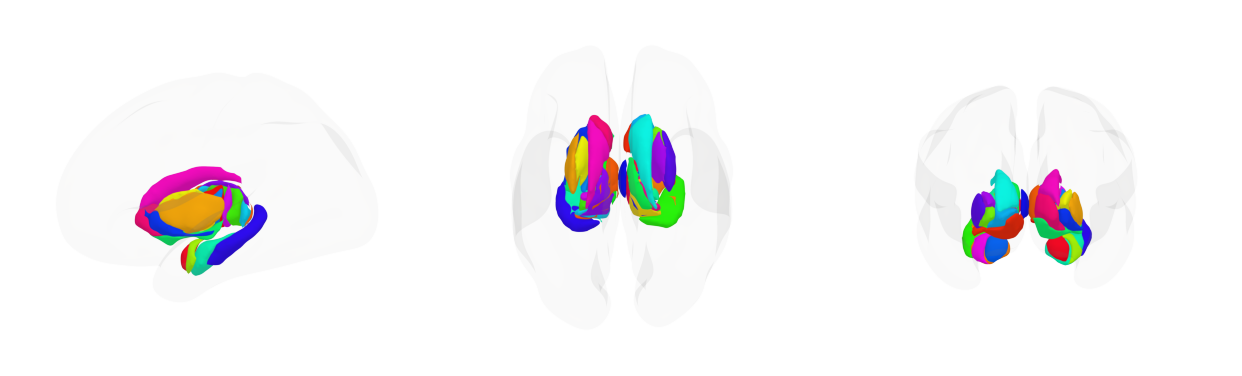

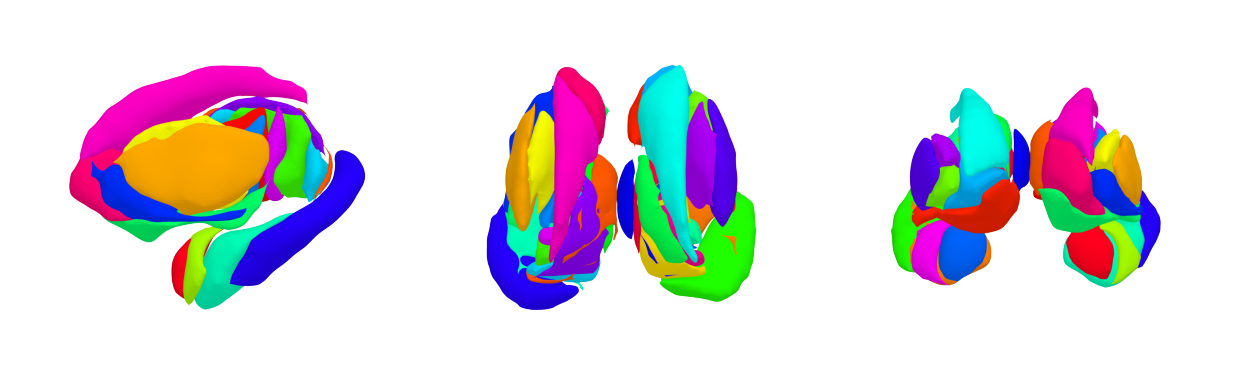

In [15]:
# styling the context brain
ax = yab.plot_subcortical(
    atlas='brainnetome_sc',
    views=['left_lateral', 'superior', 'anterior'],
    bmesh='midthickness',       # standard surface
    bmesh_alpha=0.25,            # less transparent
    bmesh_color='gray',         # dark background mesh
)
ax = yab.plot_subcortical(
    atlas='brainnetome_sc',
    views=['left_lateral', 'superior', 'anterior'],
    bmesh='inflated',         # inflated surface
    bmesh_alpha=0.1,         # very transparent
    bmesh_color='gray',       # dark background mesh
)

# hiding the context brain
ax = yab.plot_subcortical(
    atlas='brainnetome_sc',
    views=['left_lateral', 'superior', 'anterior'],
    bmesh=None,               # no context surface
)

## 3. handling missing data (nan)
when plotting dictionaries or incomplete arrays, you can control how missing regions appear using `nan_color` and `nan_alpha`.

Context leak detected, CoreAnalytics returned false


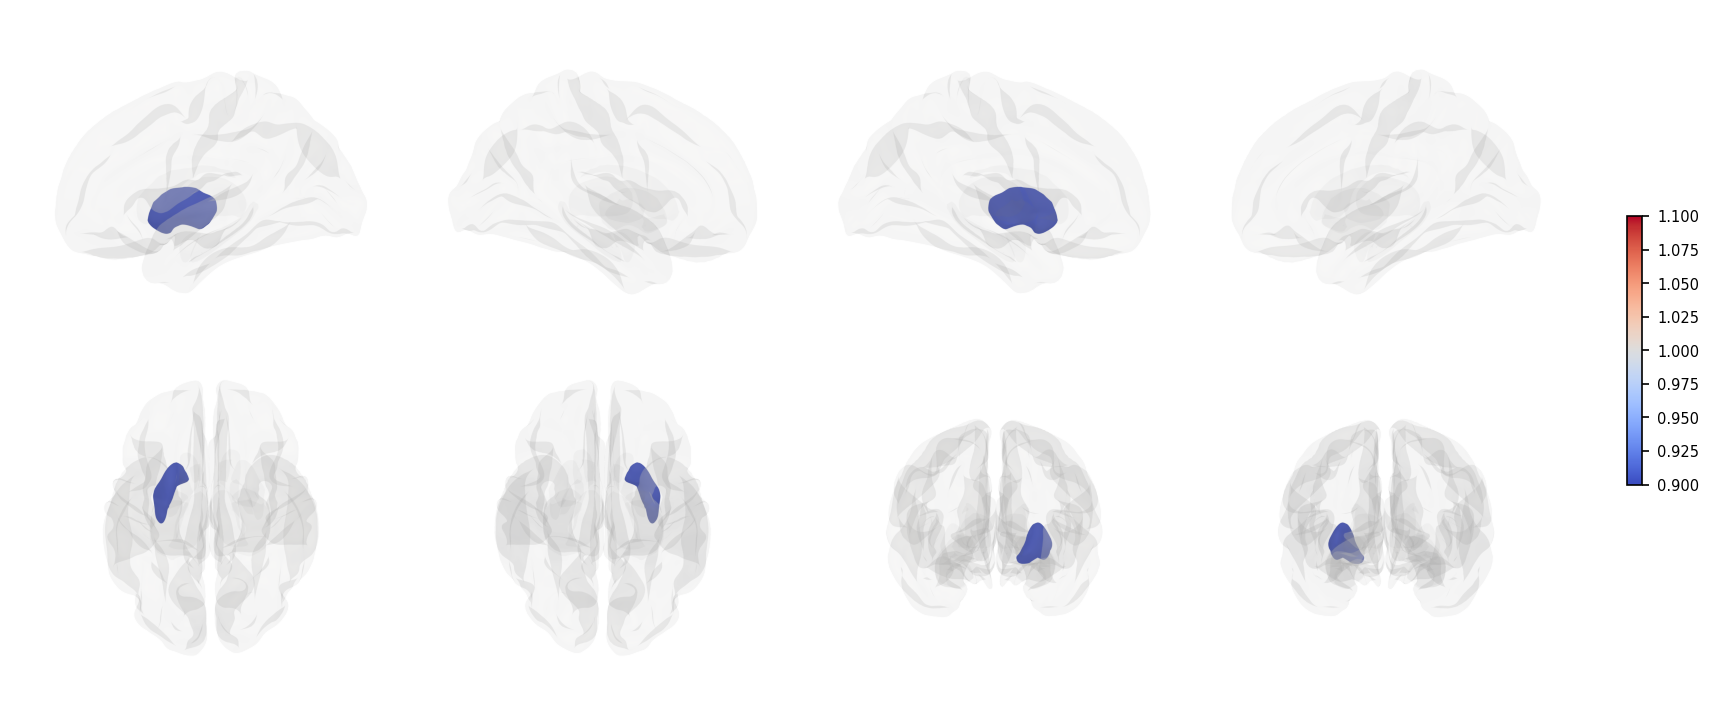

In [19]:
# define data for only one region
sparse_data = {'Left-Putamen': 1.0}

ax = yab.plot_subcortical(
    data=sparse_data,
    atlas='aseg',
    # make missing regions white and almost transparent
    nan_color='gray',
    nan_alpha=0.05,
    style='matte'
)

## 4. tract customization
for white matter tracts, you can pass specific parameters to pyvista to change the rendering of lines/tubes via `tract_kwargs`.

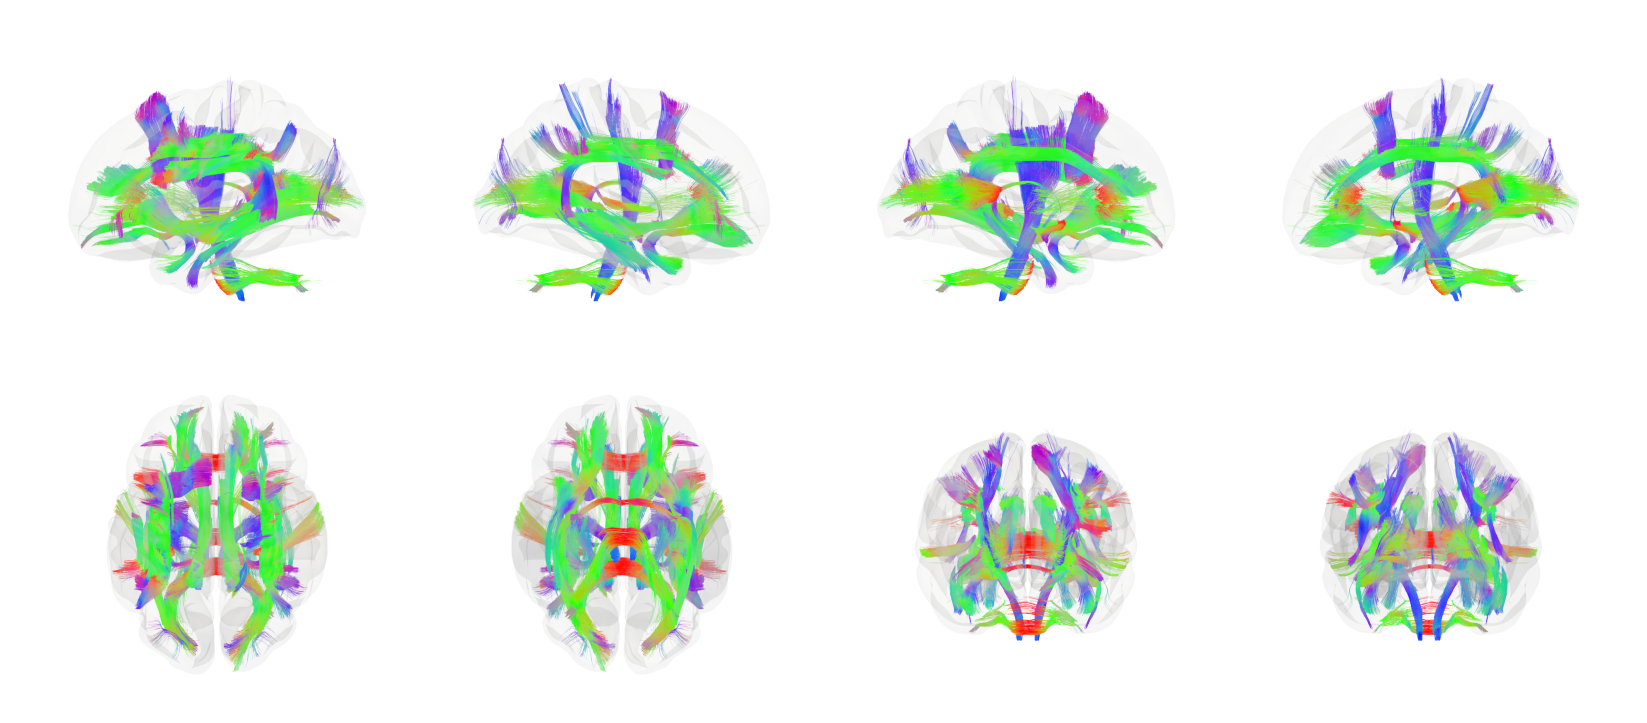

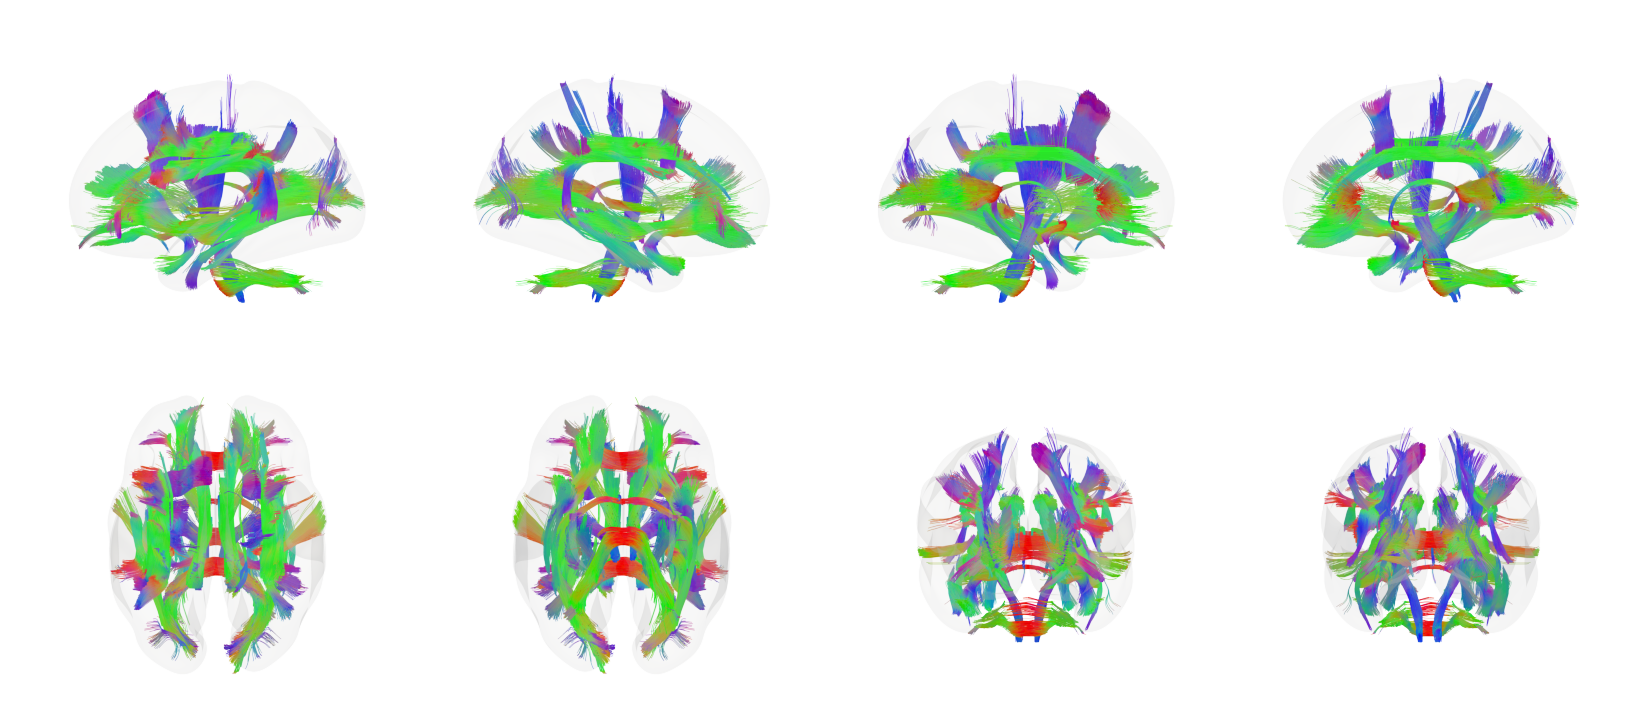

In [18]:
# render tracts as thin lines instead of 3d tubes (faster, different look)
ax = yab.plot_tracts(
    atlas='xtract_medium',
    orientation_coloring=True,
    bmesh='pial',
    tract_kwargs={
        'render_lines_as_tubes': False,  # simple lines
        'line_width': 2.0                # slightly thicker lines
    },
)

# render as thick tubes
ax = yab.plot_tracts(
    atlas='xtract_medium',
    orientation_coloring=True,
    bmesh='inflated',
    tract_kwargs={
        'render_lines_as_tubes': True,
        'line_width': 4.0  # very thick tubes
    },
)

## 5. region boundary contours (`draw_contours`)

`plot_cortical` can overlay boundary lines between atlas regions directly on the surface mesh.

pass `draw_contours=True` for a quick default, or a dict to control style:

| key | default | description |
|---|---|---|
| `color` | `'black'` | line color (any matplotlib color) |
| `line_width` | `2.0` | line width in screen pixels |
| `opacity` | `1.0` | line opacity (0–1) |
| `include_nan` | `True` | if `False`, suppresses borders touching regions with no data |

In [ ]:
atlas = 'schaefer100'
regions = yab.get_atlas_regions(atlas=atlas, category='cortical')

# sparse data: only assign values to ~60% of regions
rng = np.random.default_rng(42)
data = {r: float(v) for r, v in zip(regions, rng.random(len(regions)))}
for r in regions[60:]:
    data[r] = np.nan

fig, axes = plt.subplots(3, 1, figsize=(8, 6), dpi=200)

# default contours — borders around every region boundary
axes[0] = yab.plot_cortical(
    atlas=atlas, data=data, ax=axes[0],
    views=['left_lateral', 'superior', 'left_medial'],
    draw_contours=True,
    cmap='viridis',
)
axes[0].set_title('draw_contours=True  (all borders)', fontsize=7)

# custom style — thinner white lines
axes[1] = yab.plot_cortical(
    atlas=atlas, data=data, ax=axes[1],
    views=['left_lateral', 'superior', 'left_medial'],
    draw_contours={'color': 'white', 'line_width': 1.0, 'opacity': 0.8},
    cmap='viridis',
)
axes[1].set_title("draw_contours={'color': 'white', 'line_width': 1.0}", fontsize=7)

# include_nan=False — borders only where both sides have data
axes[2] = yab.plot_cortical(
    atlas=atlas, data=data, ax=axes[2],
    views=['left_lateral', 'superior', 'left_medial'],
    draw_contours={'color': 'black', 'line_width': 2.0, 'include_nan': False},
    cmap='viridis',
)
axes[2].set_title("draw_contours={'include_nan': False}  (skip NaN borders)", fontsize=7)

plt.tight_layout()